# 01 - Data Cleaning Inspection
---
This notebook performs an initial exploration of the dataset, with the aims of identity problems in the data quality. It loads the raw dataset from `data/raw/` and :
- identifies and handles missing data;
- identify possible duplicates and their nature.

The notebook does not perform the final cleaning phase and does not store the cleaned dataset.

## Import libraries and set the paths

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from fraud_dynamic_ensemble.config import RAW_DATA_DIR, FIGURES_DIR

2025-11-06 23:12:28.520 | INFO     | fraud_dynamic_ensemble.config:<module>:12 - PROJ_ROOT path is: /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Dynamic-Ensemble-Learning-for-Credit-Card-Fraud-Detection


In [2]:
input_path : Path = RAW_DATA_DIR / "credit_card_fraud_subsample.csv"
print(f"Loading dataset at path:\n\t{input_path}")

Loading dataset at path:
	/home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Dynamic-Ensemble-Learning-for-Credit-Card-Fraud-Detection/data/raw/credit_card_fraud_subsample.csv


In [3]:
FIGURES_DATA_CLEANING_DIR = FIGURES_DIR / "data_cleaning"
FIGURES_DATA_CLEANING_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 16})

## Data Loading
We begin by loading the raw credit card fraud dataset. This is the untouched file downloaded from Kaggle. It contains anonymized PCA components (`V1`–`V28`), `Time`, `Amount`, and the `Class` label.


In [5]:
df = pd.read_csv(input_path, header=0, sep=",")
print(f"rows, cols = {df.shape}")

rows, cols = (10000, 31)


In [6]:
df.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,81072.0,0.152504,-0.529875,1.176965,-1.202292,-0.797599,0.360677,-0.748678,0.153178,-2.342317,1.419900,-1.345154,-2.362154,-0.849474,-0.037927,1.929614,-0.975201,1.133993,0.364160,1.548788,-0.094452,-0.257429,-0.426723,-0.139358,-0.987510,0.172512,0.135781,0.012291,-0.062251,26.00,0
1,32563.0,-2.198490,1.111433,0.962725,2.770526,0.265426,1.730794,-0.505490,-2.987673,-1.322962,1.246228,1.590589,0.579804,-0.024280,0.551343,1.049448,-0.320581,0.482394,-0.233358,0.350471,-1.436321,3.052520,-0.083206,0.490815,-0.266094,-0.420221,0.340255,0.667370,-0.063418,136.90,0
2,27304.0,-3.532802,-2.228579,-0.903098,3.380612,0.658313,0.899873,1.017552,0.481798,-1.527926,0.955356,0.021979,-0.154458,0.041484,0.989967,0.896661,0.404314,-0.251155,0.603030,1.154138,0.838649,0.135297,-0.083653,-0.024973,-1.254693,-0.267784,0.246260,0.618960,-0.047699,526.19,0
3,82271.0,1.253673,0.100741,-0.198298,1.077423,0.457483,0.596458,-0.006270,0.114836,0.501890,-0.102265,-1.917463,-0.336567,-0.647918,0.134855,0.091742,-0.279249,-0.200892,-0.427931,0.163081,-0.184951,-0.199677,-0.377854,-0.230479,-1.340867,0.822117,-0.223347,0.032285,0.000885,12.99,0
4,141715.0,-0.186972,1.083575,-0.393382,1.096913,1.929655,-0.722338,1.385346,-0.378026,-0.594949,-0.587922,-0.828077,-1.025771,-1.196230,-1.031052,0.052928,-0.713127,1.256395,0.460694,0.662168,0.081869,0.004281,0.254329,-0.353016,0.470720,0.165008,-0.405059,0.004793,-0.023925,1.00,0
5,114438.0,2.019996,-0.173207,-1.198359,0.238268,0.024159,-0.711387,0.063451,-0.148303,0.361163,0.248805,0.605710,0.815965,-0.350545,0.532566,-0.593111,0.204099,-0.632505,-0.220106,0.555146,-0.205027,-0.256256,-0.683155,0.283054,-0.346035,-0.303077,0.198399,-0.079621,-0.072240,12.99,0
6,43249.0,-0.497267,0.544434,1.721015,2.834881,0.789901,2.425681,-0.239163,0.892308,-0.986532,0.596621,1.355438,0.124575,-1.594432,0.445087,0.303657,-1.653347,1.485863,-1.405883,-0.108395,-0.062258,0.235961,0.903634,0.077668,-1.029327,-0.863629,0.331711,0.250410,0.153754,18.31,0
7,29755.0,1.269032,0.188296,-0.054703,0.453526,-0.095770,-0.689943,0.148671,-0.091481,-0.208662,0.178276,0.944896,0.313726,-0.863840,0.764716,0.209747,0.332450,-0.607437,0.221849,0.307784,-0.151961,-0.039536,-0.149271,-0.099477,0.015003,0.554675,0.373752,-0.061152,-0.009992,1.23,0
8,75824.0,-2.901310,-2.562950,0.141820,0.951166,6.158854,1.444456,-1.831255,1.200281,-1.102496,0.324525,-0.698106,-0.330083,-0.065760,0.444710,-0.089729,1.130994,-1.441644,0.460105,-1.568835,0.824386,0.467758,0.063120,0.402238,0.981169,0.325867,-0.096035,-0.043987,0.198181,22.70,0
9,151029.0,-3.818214,2.551338,-4.759158,1.636967,-1.167900,-1.678413,-3.144732,1.245106,-1.692541,-4.759931,3.642257,-4.165202,0.703070,-7.624316,-1.498012,-4.079992,-6.717177,-1.887550,1.356748,0.164453,0.837685,0.761712,-0.417694,-0.469712,-0.225934,0.586415,-0.348107,0.087777,10.70,1


In [7]:
df.tail(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
9990,164023.0,2.168360,-0.616812,-1.373506,-0.618756,-0.362720,-0.812696,-0.299242,-0.273479,-0.927794,1.139637,0.558630,0.619192,0.666706,0.382696,-0.239421,-1.195189,-0.600188,1.612141,-0.585515,-0.560788,-0.115346,0.235861,0.070681,-0.293904,-0.031273,0.787418,-0.066780,-0.077536,9.00,0
9991,131687.0,-2.738393,0.856177,0.955086,1.273303,-0.236039,-0.154431,-0.191244,0.654851,0.537639,0.095164,-1.604408,0.036538,-0.935530,0.061700,-0.576405,-0.738767,0.639264,-0.593293,1.280931,-0.229981,-0.593867,-1.455025,-0.533117,-0.131935,0.296130,-0.850980,-0.374572,-0.201732,23.48,0
9992,34898.0,1.182842,-0.165058,0.666152,-0.174435,-0.702731,-0.361431,-0.429809,0.144967,0.218390,-0.068725,1.762231,0.711302,-0.673829,0.498891,0.861154,0.281873,-0.224458,-0.357426,-0.112473,-0.135479,-0.049061,-0.163063,0.147598,0.268634,-0.034818,0.906257,-0.062110,-0.003532,2.00,0
9993,156685.0,-0.129778,0.141547,-0.894702,-0.457662,0.810608,-0.504723,1.373588,-0.209476,0.208494,-1.613618,-0.800150,0.501435,1.118014,-1.816384,-0.681283,0.105946,0.716591,0.205285,-0.051322,0.399447,-0.032643,-0.246526,0.484108,0.359637,-0.435972,-0.248480,0.021527,0.109192,187.11,1
9994,81537.0,1.057682,-0.410233,1.340479,0.260212,-1.234258,-0.253500,-0.622132,0.069289,0.866368,-0.487865,0.254576,1.352689,1.155084,-0.616894,0.383497,-0.336242,0.330174,-1.150700,-0.347916,0.047675,-0.016912,0.141218,0.105339,0.729870,-0.006317,0.978204,-0.016939,0.028182,49.90,0
9995,46411.0,-0.398389,-0.816029,1.281611,-2.615637,-1.445505,0.089238,0.525184,-0.399513,-1.788747,0.951604,-1.498362,-1.781144,0.270098,-0.880397,0.218199,0.305328,-0.386488,0.701203,-0.839093,-0.307108,-0.052660,0.388737,0.021234,-0.485385,-0.320119,-0.333523,-0.039478,-0.124951,209.00,0
9996,149676.0,-0.033355,0.583958,0.101265,-0.804740,1.483008,-0.051579,0.948446,-0.332834,0.168886,-0.445488,0.523283,-0.424561,-0.895559,-1.418088,-0.515222,0.698950,-0.139361,1.038958,0.138864,-0.000537,-0.096861,0.028500,-0.332669,0.002561,-0.212138,0.366246,-0.437110,-0.404176,4.94,0
9997,83206.0,-1.464658,0.736234,2.020362,0.290575,-0.391890,-0.375046,0.182042,0.615163,-0.501685,-1.041104,-0.421012,-0.192480,-0.738587,0.493119,0.920352,0.385420,-0.221727,-0.111950,-1.614785,-0.117757,0.305150,0.498202,-0.123988,0.376237,0.411137,-0.375775,-0.066239,-0.030260,60.00,0
9998,164776.0,1.947737,0.009899,-1.244776,1.302383,0.040133,-1.067379,0.301814,-0.311473,0.330881,0.328189,-0.865231,-0.142368,-0.600555,0.643363,0.646478,-0.061264,-0.526809,-0.009001,-0.695012,-0.237873,0.279370,0.832769,-0.026910,-0.020475,0.268850,-0.425449,-0.005599,-0.046730,42.80,0
9999,55505.0,1.217761,0.362682,0.440734,0.773237,-0.507016,-1.248364,0.128681,-0.246997,-0.044512,-0.297386,0.285912,0.531497,0.525039,-0.336698,1.032236,0.367952,0.093147,-0.447329,-0.326221,-0.051879,-0.257134,-0.745197,0.158139,0.681630,0.181604,0.072146,-0.021877,0.036317,9.99,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    10000 non-null  float64
 1   V1      10000 non-null  float64
 2   V2      10000 non-null  float64
 3   V3      10000 non-null  float64
 4   V4      10000 non-null  float64
 5   V5      10000 non-null  float64
 6   V6      10000 non-null  float64
 7   V7      10000 non-null  float64
 8   V8      10000 non-null  float64
 9   V9      10000 non-null  float64
 10  V10     10000 non-null  float64
 11  V11     10000 non-null  float64
 12  V12     10000 non-null  float64
 13  V13     10000 non-null  float64
 14  V14     10000 non-null  float64
 15  V15     10000 non-null  float64
 16  V16     10000 non-null  float64
 17  V17     10000 non-null  float64
 18  V18     10000 non-null  float64
 19  V19     10000 non-null  float64
 20  V20     10000 non-null  float64
 21  V21     10000 non-null  float64
 22 

In [9]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,94556.430200,-0.232423,0.179783,-0.357002,0.212654,-0.124602,-0.070630,-0.261804,0.034599,-0.111454,-0.268734,0.185869,-0.286924,-0.004873,-0.343473,-0.012851,-0.208500,-0.302302,-0.104746,0.046275,0.021376,0.034720,0.003403,-0.000442,-0.009036,-0.005892,0.001819,0.009840,0.004504,88.343145,0.049200
std,47476.185696,2.591826,1.970276,2.599102,1.802081,1.894479,1.400646,2.284173,1.848990,1.333441,1.936584,1.405581,1.934974,0.994883,1.995975,0.933240,1.481602,2.239196,1.143580,0.869072,0.757856,1.112734,0.771793,0.637262,0.609786,0.538342,0.482085,0.484606,0.335693,224.618573,0.216296
min,0.000000,-30.552380,-29.336007,-31.103685,-4.790224,-22.105532,-17.282140,-43.557242,-41.044261,-13.434066,-24.588262,-3.423222,-18.683715,-3.642446,-19.214325,-4.498945,-14.129855,-25.162799,-9.498746,-4.366767,-18.757060,-22.797604,-8.887017,-19.254328,-2.836627,-4.781606,-1.535092,-7.263482,-8.307955,0.000000,0.000000
25%,54051.750000,-1.008727,-0.567822,-1.074893,-0.806092,-0.724259,-0.820519,-0.624710,-0.210099,-0.713535,-0.621370,-0.723857,-0.510200,-0.653882,-0.523526,-0.607559,-0.554162,-0.527210,-0.553615,-0.445137,-0.214131,-0.221082,-0.539801,-0.168963,-0.361972,-0.328923,-0.330272,-0.069869,-0.052267,4.937500,0.000000
50%,85083.500000,-0.061033,0.111359,0.081684,0.055539,-0.057702,-0.301126,0.020360,0.030040,-0.075087,-0.124788,0.041132,0.102380,-0.015135,0.016417,0.029551,0.015363,-0.078673,-0.021365,0.027822,-0.059026,-0.018758,0.008368,-0.012581,0.034864,0.017182,-0.048559,0.004797,0.012732,21.000000,0.000000
75%,139004.750000,1.281665,0.896952,0.966433,0.900644,0.637133,0.374729,0.576932,0.356684,0.578514,0.417030,0.847843,0.603441,0.647895,0.475623,0.648956,0.501425,0.405259,0.487520,0.515396,0.153456,0.204659,0.525961,0.153982,0.429143,0.353553,0.255971,0.106253,0.086981,79.000000,0.000000
max,172768.000000,2.398119,22.057729,3.770236,12.114672,28.516513,15.323769,15.915767,20.007208,7.929051,11.768124,12.018913,3.960856,3.530343,5.389864,3.881395,3.801851,8.538195,4.243841,5.228342,13.119819,27.202839,8.361985,13.750136,3.951679,2.782860,2.859167,4.610936,15.373170,5627.060000,1.000000


## Missing Values Analysis

### Visual Inspection

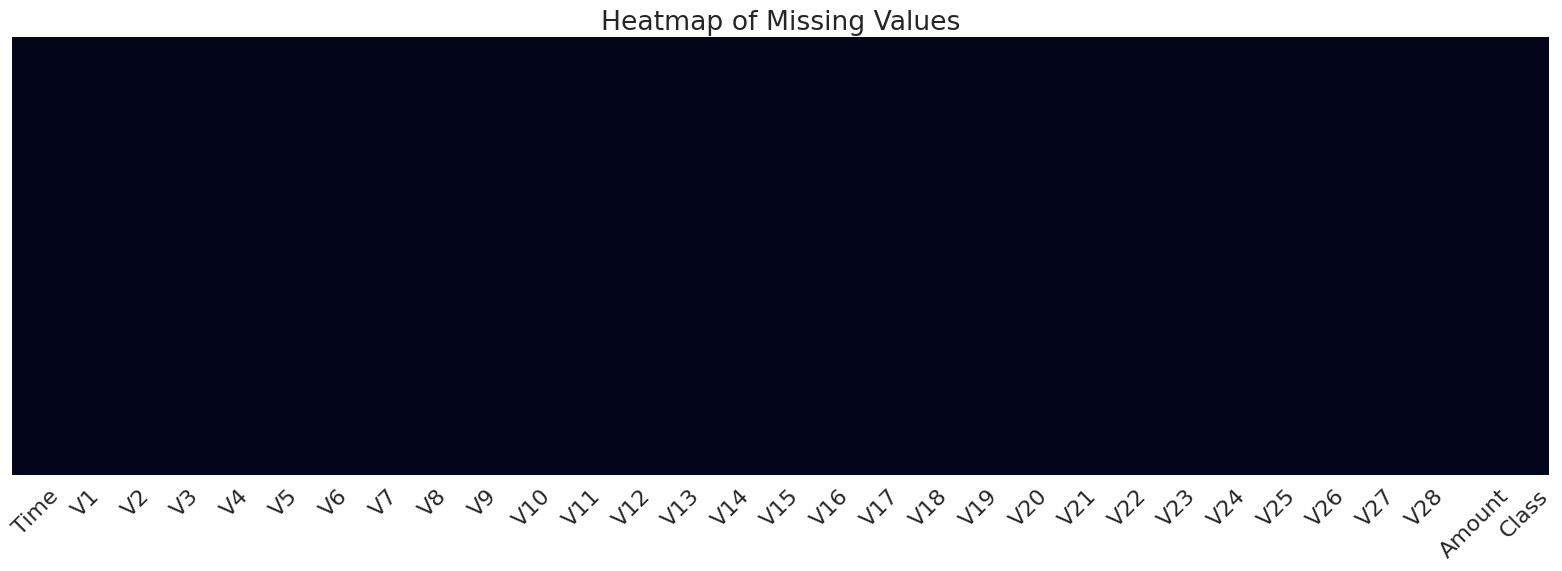

In [10]:
plt.figure(figsize=(16, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title("Heatmap of Missing Values")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DATA_CLEANING_DIR / "missing_values.png", dpi=300)
plt.show()

### Column-Level Analysis
Missing data may indicate corruption, incomplete exports, or systematic recording errors.

- **Justification:** Columns with missing data may reduce model performance and require imputation or exclusion.

- **Utility:** This step informs whether any imputation strategies might be necessary later.

In [11]:
null_cols = df.isnull().sum()
null_cols = null_cols[null_cols > 0].sort_values(ascending=False)

if null_cols.empty:
    print("No missing values detected in any column.")
else:
    print("Missing values per column:")
    for col, n_missing in null_cols.items():
        print(f" - {col}: {n_missing} ({n_missing / df.shape[0] * 100:.3f}%)")

No missing values detected in any column.


### Row-Level Analysis
Rows with mostly missing data are likely not salvageable.

- **Justification:** Imputing >50% of a row's content introduces too much uncertainty.

- **Utility:** Prevents noisy, unreliable rows from corrupting the model training phase.

In [12]:
n_before = df.shape[0]
row_null_percent = df.isnull().mean(axis=1) * 100
rows_to_drop = df[row_null_percent > 50].index
df.drop(index=rows_to_drop, inplace=True)
n_dropped = n_before - df.shape[0]

print(f"Number of rows with >50% NaNs removed: {n_dropped}/{n_before} "
      f"({n_dropped / n_before * 100:.3f}%)")

Number of rows with >50% NaNs removed: 0/10000 (0.000%)


## Class Balance
We inspect the target distribution to confirm the expected class imbalance.

- **Justification:** In fraud detection, we expect a very small percentage of transactions to be fraudulent.

- **Utility:** Confirms no accidental removal of minority class (Class = 1).

In [13]:
print("Class distribution:")
class_counts = df['Class'].value_counts()
total = class_counts.sum()
for label, count in class_counts.items():
    print(f" - Class {label}: {count} ({count / total * 100:.3f}%)")

Class distribution:
 - Class 0: 9508 (95.080%)
 - Class 1: 492 (4.920%)


## Duplicate Row Detection and Removal

Duplicate transactions may occur due to export processes or data corruption. They can bias models and falsely inflate evaluation metrics.

- **Justification:** In fraud detection, duplicates may lead to data leakage and overfitting.

- **Utility:** Ensures that each transaction is a unique signal.

In [14]:
# Total number of rows
n_total = df.shape[0]

# Identify full duplicates (excluding the first occurrence,
# we are assessing redundancy, not the total repeated rows)
n_duplicates = df.duplicated().sum()

print(f"Number of duplicate rows: {n_duplicates}/{n_total} ({n_duplicates / n_total * 100:.3f}%)")

Number of duplicate rows: 20/10000 (0.200%)


In [15]:
# Identify all duplicated rows (including the first occurrence)
duplicate_rows_all = df[df.duplicated(keep=False)]

# Group by all columns and count identical rows
duplicate_groups = (
    duplicate_rows_all
    .groupby(list(df.columns))
    .size()
    .reset_index(name="count")
    .sort_values(by="count", ascending=False)
)

print(f"Found {len(duplicate_groups)} unique duplicated row patterns.")
duplicate_groups.head(10)

Found 14 unique duplicated row patterns.


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class,count
0,68207.0,-13.192671,12.785971,-9.906650,3.320337,-4.801176,5.760059,-18.750889,-37.353443,-0.391540,-5.052502,4.406806,-4.610756,-1.909488,-9.072711,-0.226074,-6.211557,-6.248145,-3.149247,0.051576,-3.493050,27.202839,-8.887017,5.303607,-0.639435,0.263203,-0.108877,1.269566,0.939407,1.00,1,6
12,94362.0,-26.457745,16.497472,-30.177317,8.904157,-17.892600,-1.227904,-31.197329,-11.438920,-9.462573,-22.187089,4.419997,-10.592305,-0.703796,-3.926207,-2.400246,-6.809890,-12.462315,-5.501051,-0.567940,2.812241,-8.755698,3.460893,0.896538,0.254836,-0.738097,-0.966564,-7.263482,-1.324884,1.00,1,4
2,84204.0,-0.937843,3.462889,-6.445104,4.932199,-2.233983,-2.291561,-5.695594,1.338825,-4.322377,-8.099119,7.182967,-9.445943,-0.314620,-12.991466,-0.136359,-6.367524,-12.734394,-3.845130,1.007667,1.129532,1.066550,-0.521657,-0.319917,-0.405859,0.906802,1.165784,1.374495,0.729889,0.00,1,2
3,85285.0,-7.030308,3.421991,-9.525072,5.270891,-4.024630,-2.865682,-6.989195,3.791551,-4.622730,-8.409665,6.309044,-8.576761,0.246747,-11.534046,-0.364265,-5.452495,-11.887570,-3.563585,0.876019,0.545698,1.103398,-0.541855,0.036943,-0.355519,0.353634,1.042458,1.359516,-0.272188,0.00,1,2
4,85285.0,-6.713407,3.921104,-9.746678,5.148263,-5.151563,-2.099389,-5.937767,3.578780,-4.684952,-8.537758,6.348979,-8.681609,0.251179,-11.608002,-0.351569,-5.363566,-11.939092,-3.583603,0.897402,0.135711,0.954272,-0.451086,0.127214,-0.339450,0.394096,1.075295,1.649906,-0.394905,252.92,1,2
1,84204.0,-1.927453,1.827621,-7.019495,5.348303,-2.739188,-2.107219,-5.015848,1.205868,-4.382713,-8.337707,7.190306,-9.424844,-0.223293,-12.875494,-0.071918,-6.299961,-12.719207,-3.740176,0.844060,2.172709,1.376938,-0.792017,-0.771414,-0.379574,0.718717,1.111151,1.277707,0.819081,512.25,1,2
5,85559.0,-2.647136,-0.195695,1.948912,3.335200,-0.167537,0.783678,-0.602756,0.647473,-0.769401,0.810817,0.383270,0.991192,0.828248,-0.318895,-0.715945,0.006210,0.158587,0.440653,1.662134,0.076978,-0.102669,-0.181135,-0.626975,0.085283,-0.052119,0.082113,-0.840811,-0.431696,52.41,0,2
6,93853.0,-6.185857,7.102985,-13.030455,8.010823,-7.885237,-3.974550,-12.229608,4.971232,-4.248307,-12.965481,8.688308,-17.182918,0.069577,-14.116156,0.959032,-12.375334,-18.716765,-6.522015,3.517955,0.483930,2.502772,0.481691,0.480958,0.360319,-0.293354,-0.199193,-0.203917,0.398927,44.90,1,2
8,93860.0,-10.850282,6.727466,-16.760583,8.425832,-10.252697,-4.192171,-14.077086,7.168288,-3.683242,-15.239962,8.030708,-16.060306,0.270530,-14.952981,-0.241095,-11.866731,-15.486990,-5.748652,4.130031,-0.646818,2.541637,0.135535,-1.023967,0.406265,0.106593,-0.026232,-1.464630,-0.411682,78.00,1,2
7,93853.0,-5.839192,7.151532,-12.816760,7.031115,-9.651272,-2.938427,-11.543207,4.843627,-3.494276,-13.320789,8.460244,-17.003289,0.101557,-14.094452,0.747031,-12.661696,-18.912494,-6.626975,4.008921,0.055684,2.462056,1.054865,0.530481,0.472670,-0.275998,0.282435,0.104886,0.254417,316.06,1,2


Check the frequency, that is how many groups have N duplicates.

Number of unique duplicate patterns by repetition count:
 - duplicated 2 times: 12 pattern
 - duplicated 4 times: 1 pattern
 - duplicated 6 times: 1 pattern


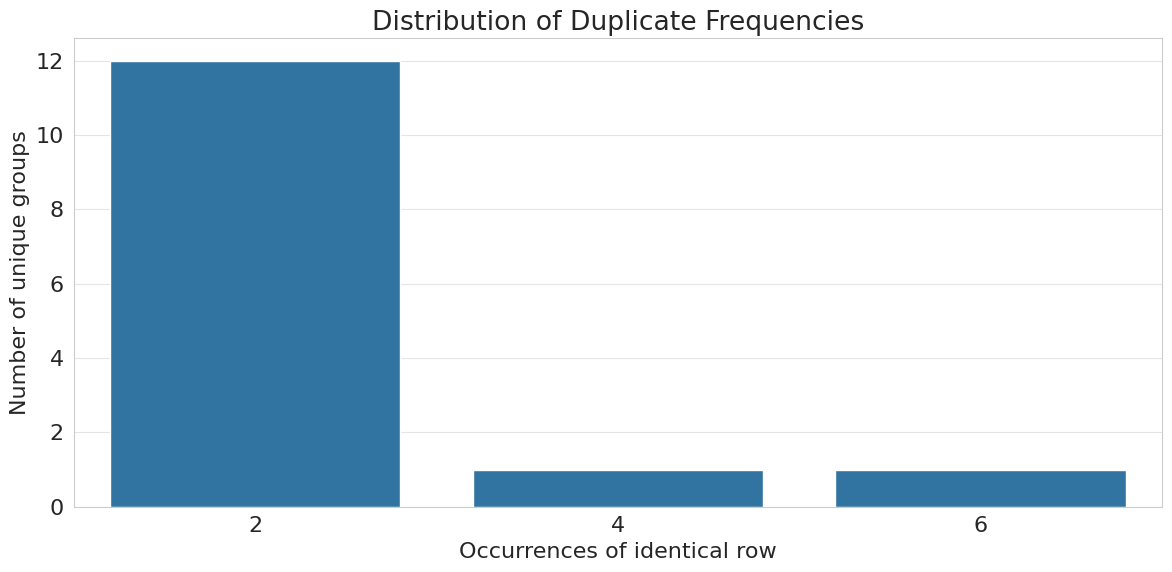

In [16]:
duplication_frequency = duplicate_groups['count'].value_counts().sort_index()
print("Number of unique duplicate patterns by repetition count:")
for repetition, num_groups in duplication_frequency.items():
    print(f" - duplicated {repetition} times: {num_groups} pattern")

plt.figure(figsize=(12, 6))
sns.barplot(x=duplication_frequency.index, y=duplication_frequency.values)
plt.xlabel("Occurrences of identical row")
plt.ylabel("Number of unique groups")
plt.title("Distribution of Duplicate Frequencies")
plt.grid(True, axis='y', alpha=0.5)
plt.tight_layout()
plt.savefig(FIGURES_DATA_CLEANING_DIR / "duplicated_frequency_distribution.png", dpi=300)
plt.show()

Check how the duplicated rows are distributed across the two classes.

In [17]:
# Count how many are Class 0 and Class 1
dup_class_counts = duplicate_rows_all['Class'].value_counts()

print("Class distribution in all duplicated rows:")
for cls, count in dup_class_counts.items():
    pct = count / len(duplicate_rows_all) * 100
    print(f" - Class {cls}: {count} rows ({pct:.4f}%)")

Class distribution in all duplicated rows:
 - Class 1: 32 rows (94.1176%)
 - Class 0: 2 rows (5.8824%)


Check duplication frequency by Class.

In [18]:
# Group by full feature set and Class label to get counts of each duplicated pattern per class
duplicate_group_class = (
    duplicate_rows_all
    .groupby(list(df.columns))
    .size()
    .reset_index(name="count")
)

# Compute frequency distribution by class
class_frequencies = (
    duplicate_group_class
    .groupby(['Class', 'count'])
    .size()
    .reset_index(name="n_patterns")
    .sort_values(['Class', 'count'])
)

print(f"\nDuplication frequency by class: ")
class_frequencies


Duplication frequency by class: 


,Class,count,n_patterns
0,0,2,1
1,1,2,11
2,1,4,1
3,1,6,1


In [19]:
n_samples = df.shape[0]
df.drop_duplicates(ignore_index=True, inplace=True)
duplicates = n_samples - df.shape[0]
print(f"Number of canceled duplicates: {duplicates}/{n_samples} ({duplicates / n_samples * 100:.3f}%)")

Number of canceled duplicates: 20/10000 (0.200%)


In [20]:
print("Class distribution after removing duplication:")
class_counts = df['Class'].value_counts()
total = class_counts.sum()
for label, count in class_counts.items():
    print(f" - Class {label}: {count} ({count / total * 100:.3f}%)")

Class distribution after removing duplication:
 - Class 0: 9507 (95.261%)
 - Class 1: 473 (4.739%)


We are working with the Credit Card Fraud Detection dataset, which contains:

- Time (in seconds)

- Amount

- 28 PCA-transformed features

- Class

When two rows match exactly in all fields, including Time, it's a very strong signal that they’re not two independent real transactions, but instead a copied entry.

Given the time (precise to the second), the amount (float) and 28 PCs, the probability that two truly distinct events would produce identical values in all 31+ columns is astronomically low, even if the same user repeated the action.

This makes true accidental “real” duplication almost impossible.

---

If we leave exact duplicates in the dataset:

1. Bias in the model—The classifier will “see” repeated evidence of the same row. This gives unfair influence to those examples during training.

2. Risk of overfitting—Especially with a small number of fraud cases, repeating exact Class 1 samples inflates the model's confidence.

3. invalidation of cross-validation—Duplicates might leak into both training and validation folds. This leads to optimistically biased performance metrics (especially precision/recall).

Based on these considerations, we adopt the choice of dropping duplicated rows, keeping each of them just one time.